# Thyroid Cancer Risk Analysis

End-to-end exploratory analysis and classical machine learning workflow for thyroid nodule diagnosis using demographic, behavioral, environmental, and clinical features.

**Repository maintainer:** Andrew Albizati

**Project context:** COMP-352 collaborative course project with AJ Yalagonda, Bilguun Erdene Ochir, and Max Jeruss

**Date:** May 20, 2025

**Dataset source:** https://www.kaggle.com/datasets/bhargavchirumamilla/thyroid-cancer-risk-dataset


# Data Importing and Pre-processing

In [7]:
import pandas as pd
pd.set_option('display.max_columns', None)

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import norm
import numpy as np
import hashlib

In [8]:
# Read the local dataset bundled with the repository
df = pd.read_csv("thyroid_cancer_risk_data.csv")


In [9]:
# Print dataset dimensions (rows, cols)
df.shape

(212691, 17)

In [10]:
# Check column data types
df.dtypes.rename("Column Datatypes")

,Column Datatypes
Patient_ID,int64
Age,int64
Gender,object
Country,object
Ethnicity,object
Family_History,object
Radiation_Exposure,object
Iodine_Deficiency,object
Smoking,object
Obesity,object


In [11]:
# Count number of categorical variables
categorical_variables = 0
for dtype in df.dtypes:
  if dtype == "object":
    categorical_variables += 1

print("Number of categorical variables:", categorical_variables)

Number of categorical variables: 11


In [12]:
# Count number of numerical variables
numeric_variables = df.shape[1] - categorical_variables - 1 # remove 1 for Patient_ID
print("Number of numerical variables:", numeric_variables)

Number of numerical variables: 5


In [13]:
# Display dataset head
df.head()

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


## Handle Missing Data

In [14]:
# Print number of missing values per column
df.isnull().sum().rename("Missing Values")

,Missing Values
Patient_ID,0
Age,0
Gender,0
Country,0
Ethnicity,0
Family_History,0
Radiation_Exposure,0
Iodine_Deficiency,0
Smoking,0
Obesity,0


From this, we can tell that we do not have any null values in our dataset. This doesn't necessarily mean there aren't any missing values however, since it could the case that missing data isn't marked as null in our numerical columns.

In [15]:
# Check for irregularities in numeric columns
df.describe()

,Patient_ID,Age,TSH_Level,T3_Level,T4_Level,Nodule_Size
count,212691.00000,212691.000000,212691.000000,212691.000000,212691.000000,212691.000000
mean,106346.00000,51.918497,5.045102,2.001727,8.246204,2.503403
std,61398.74739,21.632815,2.860264,0.866248,2.164188,1.444631
min,1.00000,15.000000,0.100000,0.500000,4.500000,0.000000
25%,53173.50000,33.000000,2.570000,1.250000,6.370000,1.250000
50%,106346.00000,52.000000,5.040000,2.000000,8.240000,2.510000
75%,159518.50000,71.000000,7.520000,2.750000,10.120000,3.760000
max,212691.00000,89.000000,10.000000,3.500000,12.000000,5.000000


## Analysis of Numerical Columns

### Age
We can see that the dataset begins with patients at age 15 and ends with patients aged 89. It is important to note that integer values are used to represent age, and that both the mean and median are around 52 years old.

### TSH_Level
According to [UCLA Health](https://www.uclahealth.org/medical-services/surgery/endocrine-surgery/conditions-treated/thyroid/normal-thyroid-hormone-levels#:~:text=TSH%20normal%20values%20are%200.5,0.7%20to%201.9ng%2FdL.), normal TSH levels in adults range from 0.5 to 5.0 mIU/L. This means that a majority of patients in our dataframe have mild hypothyroidism, which is to be expected after recovering from thyroid cancer treatment.

### T3_Level
According to [Cleveland Clinic](https://my.clevelandclinic.org/health/diagnostics/22425-triiodothyronine-t3), normal T3 levels in adults aged 18 to 99 range from 2.3 to 4.1 pg/ML. This means that none of our patient records are above the ceiling of these bounds, however the mean (2.0) is below the normal range floor (2.3). This is to be expected since many patients after recovering from thyroid cancer treatment develop mild hypothyroidism.

### T4_Level
According to [UCLA Health](https://www.uclahealth.org/medical-services/surgery/endocrine-surgery/conditions-treated/thyroid/normal-thyroid-hormone-levels#:~:text=Total%20T4%20and%20Total%20T3,5.0%20to%2012.0%CE%BCg%2FdL.), normal T4 levels in adults range from 5.0 to 12.0 μg/dL. This means that a large majority of our patient records fall within these bounds, with our minimum record being just below the floor of the normal range. Factors that may lead to this include unrelated autoimmune diseases and poor iodine intake in a patient's diet. A very large T4 level would not be expected from a patient recovering from thyroid cancer treatemnet.


### Nodule Size
According to [Associated Endocrinologists](https://www.endocrinemds.com/blogs/what-size-thyroid-nodule-should-you-worry-about/#:~:text=A%20small%20nodule%20with%20a,an%20increased%20risk%20of%20cancer.), nodules
that are less than 1cm in size are very often benign, while those greater than 2cm have a have an increased risk of being cancerous. Those with a size greater than 4cm have a high enough likelihood of being cancerous that ultrasounds often take place. What is likely happening in our dataset is that patients with smaller, likely benign nodules are less frequently included, while those with larger nodules are overrepresented due to clinical priorities of post-treatment surveillence.

## Reduce Redundant Data

In [16]:
# Try to find redundant or near-duplicate records by hashing them and comparing
df_copy = df.copy()
df_copy.drop(columns=['Patient_ID'], inplace=True)

# Round numeric columns to nearest 2
for col in df_copy.select_dtypes(include=np.number):
    df_copy[col] = (df_copy[col] // 2 * 2).astype(int)

# Group ages into 3-year bins
if 'Age' in df_copy.columns:
    df_copy['Age'] = (df_copy['Age'] // 3 * 3).astype(int)

# Normalize categorical data
for col in df_copy.select_dtypes(exclude=np.number):
    df_copy[col] = (
        df_copy[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

# Generate hash per row
df_copy['hash'] = df_copy.astype(str).agg('|'.join, axis=1).apply(
    lambda x: hashlib.md5(x.encode()).hexdigest()
)

# Count similar groups
dupe_counts = df_copy['hash'].value_counts()
similar_rows = dupe_counts[dupe_counts > 1]

# Output results
print(f"Similar row groups found: {len(similar_rows)}")
print(f"Total rows involved: {similar_rows.sum()}")

Similar row groups found: 3467
Total rows involved: 7063


Even with this method of data reduction, only 3.3% of the data is near redundant. Removing these records would result in minimal reduction in dataset size, and would be unlikely to have a noticible impact in model performance. By making this algorithm less sensitive, we risk losing data that will cause our model to fail at finding patterns in the data.

Therefore, retaining them would preserve the richness and natural distribution of the data, which will be essential in creating a robust model in a healthcare context.

## Handle Outlier Data

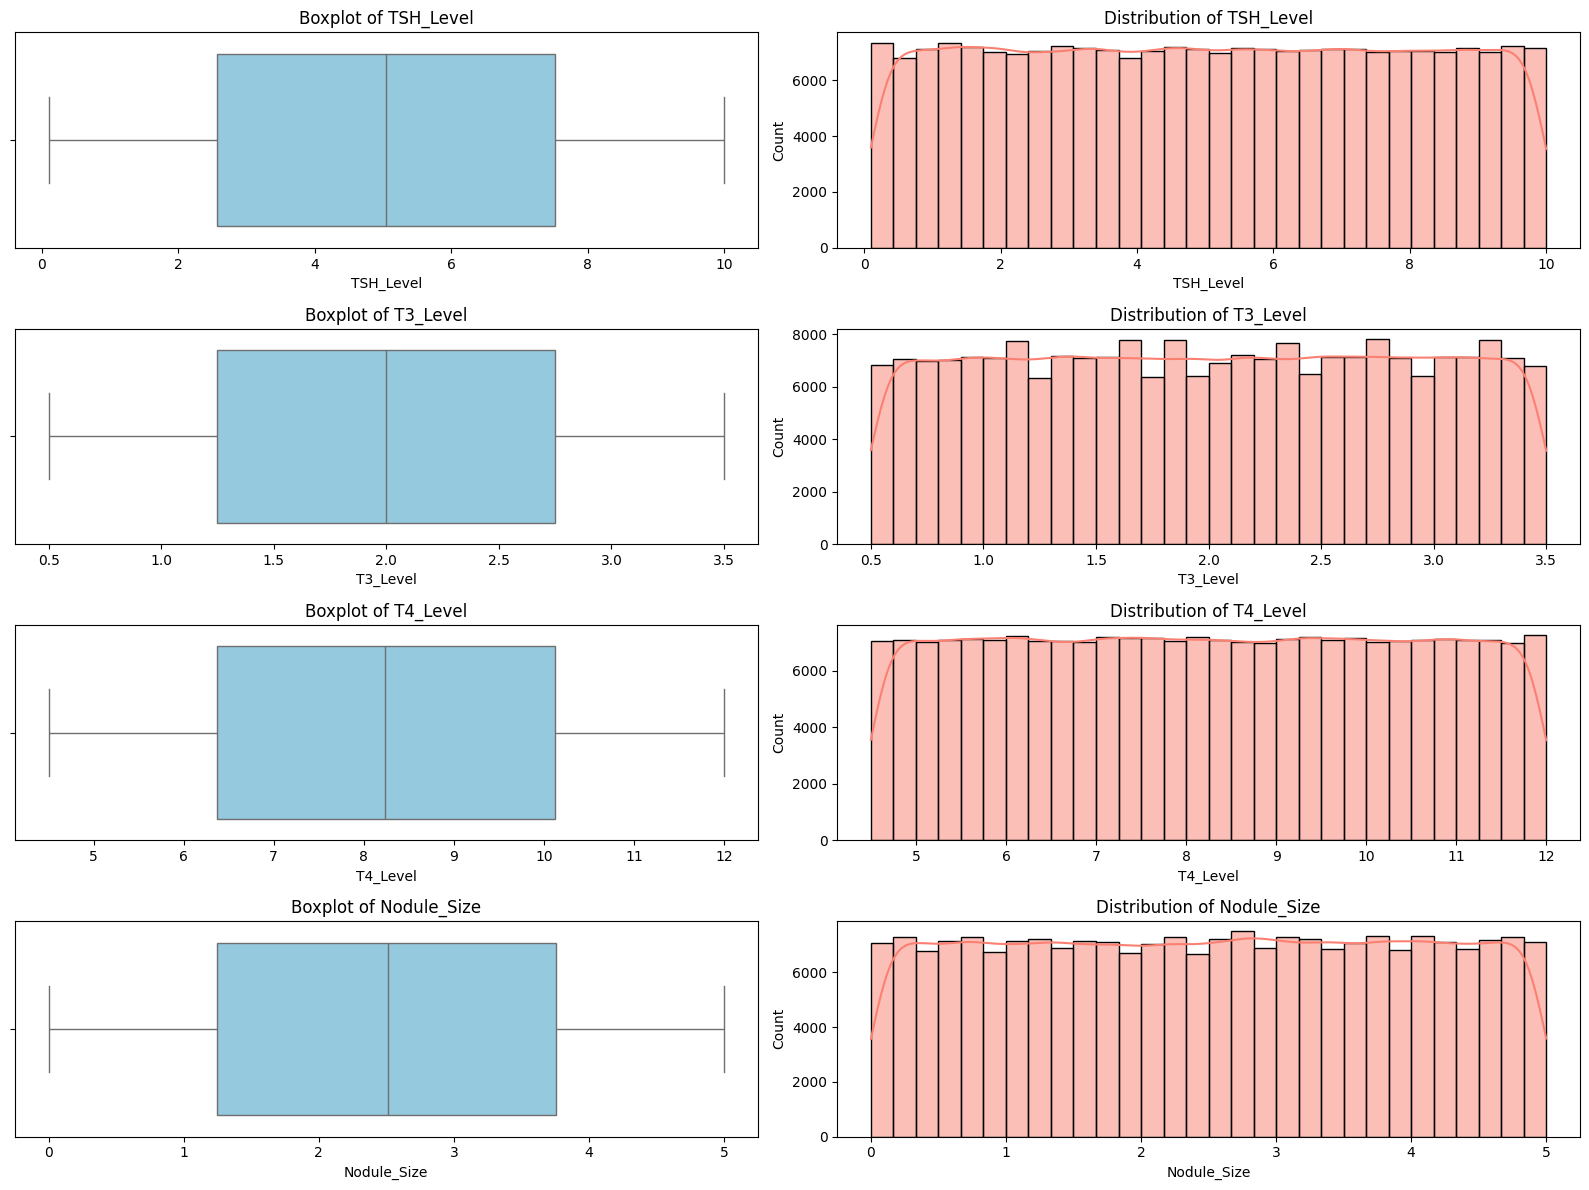

In [17]:
numeric_features = ['TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size']

# Set up subplots for boxplots and histograms
plt.figure(figsize=(16, 12))

for i, col in enumerate(numeric_features):
    # Boxplot
    plt.subplot(len(numeric_features), 2, 2*i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

    # Histogram
    plt.subplot(len(numeric_features), 2, 2*i + 2)
    sns.histplot(df[col], kde=True, color='salmon', bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

We can see from our four main numerical variables that there aren't any outliers detected since the dataset likely has predefined cutoff values, which are intended to cap the data within clinically relevant ranges. This heavily implies that the data has undergone prior cleaning.

## Encode Categorical Columns and Normalize Numerical Columns

In [18]:
encoded_df = df.copy()

# Drop Patient_ID and Age
encoded_df.drop(columns=['Patient_ID'], inplace=True)

# One-hot encode Country and Ethnicity into binary 0/1 columns
encoded_df = pd.get_dummies(encoded_df, columns=['Country', 'Ethnicity'], prefix=['Country', 'Ethnicity'])
bool_cols = encoded_df.select_dtypes(include='bool').columns
encoded_df[bool_cols] = encoded_df[bool_cols].astype(int)

# Encode original boolean columns with No = 0 and Yes = 1
boolean_cols = [
    'Family_History',
    'Radiation_Exposure',
    'Iodine_Deficiency',
    'Smoking',
    'Obesity',
    'Diabetes'
]
for col in boolean_cols:
    encoded_df[col] = encoded_df[col].map({'Yes': 1, 'No': 0})

# Encode Gender: Male = 1, Female = 0
encoded_df['Gender'] = encoded_df['Gender'].map({'Male': 1, 'Female': 0})

# Ordinally encode Thyroid_Cancer_Risk: Low = 0, Medium = 1, High = 2
encoded_df['Thyroid_Cancer_Risk'] = encoded_df['Thyroid_Cancer_Risk'].map({'Low': 0, 'Medium': 1, 'High': 2})

# Encode Diagnosis: Benign = 0, Malignant = 1
encoded_df['Diagnosis'] = encoded_df['Diagnosis'].map({'Benign': 0, 'Malignant': 1})

encoded_df.head()

,Age,Gender,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis,Country_Brazil,Country_China,Country_Germany,Country_India,Country_Japan,Country_Nigeria,Country_Russia,Country_South Korea,Country_UK,Country_USA,Ethnicity_African,Ethnicity_Asian,Ethnicity_Caucasian,Ethnicity_Hispanic,Ethnicity_Middle Eastern
0,66,1,0,1,0,0,0,0,9.37,1.67,6.16,1.08,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
1,29,1,0,1,0,0,0,0,1.83,1.73,10.54,4.05,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
2,86,1,0,0,0,0,0,0,6.26,2.59,10.57,4.61,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
3,75,0,0,0,0,0,0,0,4.10,2.62,11.04,2.46,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
4,35,0,1,1,0,0,0,0,9.10,2.11,10.71,2.11,2,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0


In [19]:
# Normalize numerical features for better performance with linear models
# We won't discretize these variables since we want to detect subtle patterns
numeric_cols = ['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size']

scaler = StandardScaler()
encoded_df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

encoded_df.head()

,Age,Gender,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis,Country_Brazil,Country_China,Country_Germany,Country_India,Country_Japan,Country_Nigeria,Country_Russia,Country_South Korea,Country_UK,Country_USA,Ethnicity_African,Ethnicity_Asian,Ethnicity_Caucasian,Ethnicity_Hispanic,Ethnicity_Middle Eastern
0,0.650934,1,0,1,0,0,0,0,1.512066,-0.382947,-0.963968,-0.985308,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
1,-1.059435,1,0,1,0,0,0,0,-1.124060,-0.313683,1.059890,1.070585,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
2,1.575458,1,0,0,0,0,0,0,0.424751,0.679107,1.073752,1.458229,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
3,1.066970,0,0,0,0,0,0,0,-0.330426,0.713739,1.290924,-0.030045,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
4,-0.782077,0,1,1,0,0,0,0,1.417669,0.124991,1.138441,-0.272322,2,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0


## Feature Engineering

In [20]:
# We will create 3 new features:
# Size_Age_Interaction -- Combining these variables captures a potiential compounding effect
# TSH_T3_Ratio --  Reflects the feedback loop in thyroid hormone regulation
# Thyroid_Index -- Combine the activity of TSH and T4, both central to thyroid function
temp_features = pd.DataFrame({
    'Size_Age_Interaction': df['Nodule_Size'] * df['Age'],
    'TSH_T3_Ratio': df['TSH_Level'] / (df['T3_Level'] + 1e-3),
    'Thyroid_Index': df['TSH_Level'] * df['T4_Level']
})

# Standardize the features
scaler = StandardScaler()
standardized_values = scaler.fit_transform(temp_features)

# Add standardized features to encoded_df
encoded_df['Size_Age_Interaction'] = standardized_values[:, 0]
encoded_df['TSH_T3_Ratio'] = standardized_values[:, 1]
encoded_df['Thyroid_Index'] = standardized_values[:, 2]
encoded_df.head()

,Age,Gender,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis,Country_Brazil,Country_China,Country_Germany,Country_India,Country_Japan,Country_Nigeria,Country_Russia,Country_South Korea,Country_UK,Country_USA,Ethnicity_African,Ethnicity_Asian,Ethnicity_Caucasian,Ethnicity_Hispanic,Ethnicity_Middle Eastern,Size_Age_Interaction,TSH_T3_Ratio,Thyroid_Index
0,0.650934,1,0,1,0,0,0,0,1.512066,-0.382947,-0.963968,-0.985308,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,-0.601002,0.802613,0.603515
1,-1.059435,1,0,1,0,0,0,0,-1.124060,-0.313683,1.059890,1.070585,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,-0.127857,-0.758028,-0.835194
2,1.575458,1,0,0,0,0,0,0,0.424751,0.679107,1.073752,1.458229,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,2.731407,-0.291964,0.919814
3,1.066970,0,0,0,0,0,0,0,-0.330426,0.713739,1.290924,-0.030045,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0.559264,-0.584104,0.137240
4,-0.782077,0,1,1,0,0,0,0,1.417669,0.124991,1.138441,-0.272322,2,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,-0.574665,0.357881,2.091297


# Data Analysis and Visualization

**Categorical variables**: Gender, Country, Ethniciy, Family History, Radiation Exposure, Iodine Deficiency, Smoking, Obesity, Diabetes, Diagnosis

**Ordinal variables**: Thyroid Cancer Risk

**Numerical Variables**: Age, TSH Level, T3 Level, T4 Level, Nodule Size

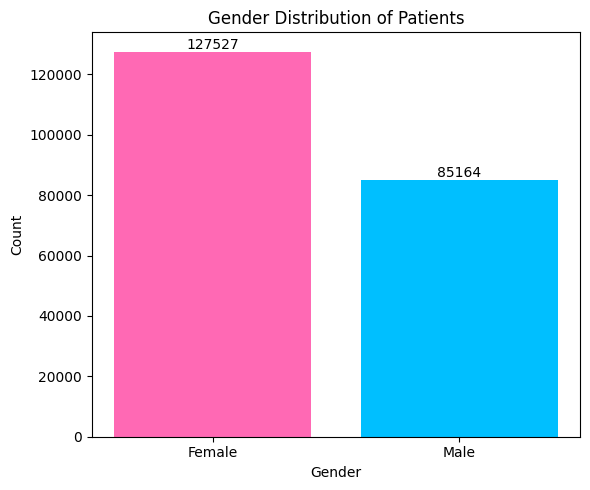

In [21]:
# Make barchart of gender distribution
gender_counts = df['Gender'].value_counts()

color_map = {'Female': '#FF69B4', 'Male': '#00BFFF'}
bar_colors = [color_map[gender] for gender in gender_counts.index]

plt.figure(figsize=(6, 5))
bars = plt.bar(gender_counts.index, gender_counts.values, color=bar_colors)
plt.title('Gender Distribution of Patients')
plt.xlabel('Gender')
plt.ylabel('Count')

# Add count labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

The bar chart displays the breakdown of patients by gender in the thyroid cancer risk dataset. Females (127,527) significantly outnumber males (85,164), reflecting known epidemiological patterns—thyroid disorders and cancer occur more frequently in women. When training predictive models, it’s important to account for this imbalance to avoid bias against underrepresented groups. Techniques such as stratified sampling or class-weight adjustments can help ensure fair performance across genders.

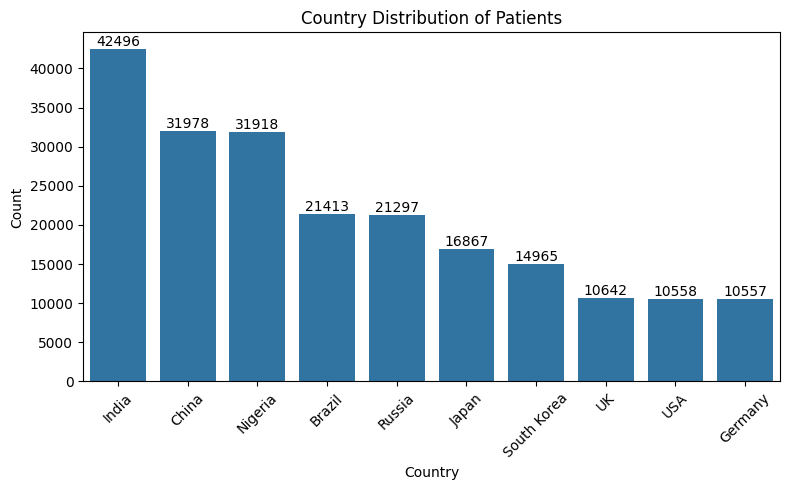

In [22]:
# Make barchart of country distribution with count labels
country_counts = df['Country'].value_counts()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=country_counts.index, y=country_counts.values)
plt.title('Country Distribution of Patients')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Add count labels above bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

This bar chart shows the number of patients from each country in the thyroid cancer risk dataset. India has the highest representation, followed by China and Nigeria. This uneven distribution may reflect data collection sources or population size. It's important to consider these proportions when analyzing the data, as overrepresented countries could skew global insights or introduce bias if not properly accounted for during model training and evaluation.

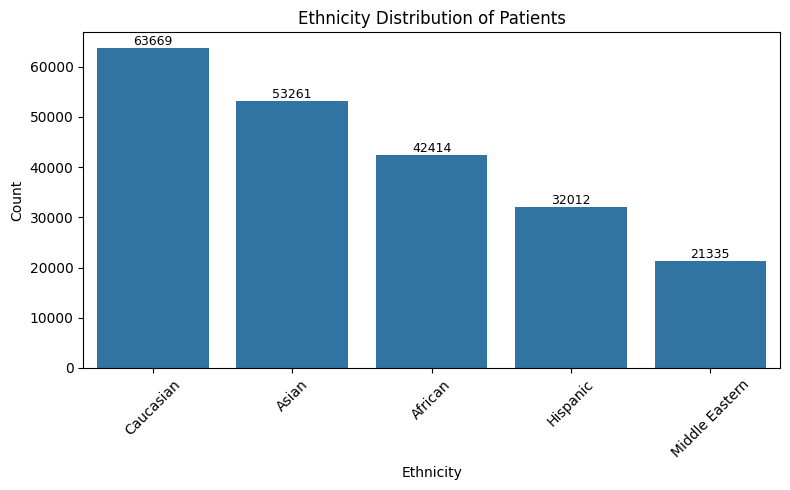

In [23]:
# Make barchart of ethnicity distribution with count labels
ethnicity_counts = df['Ethnicity'].value_counts()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=ethnicity_counts.index, y=ethnicity_counts.values)

plt.title('Ethnicity Distribution of Patients')
plt.xlabel('Ethnicity')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Add count labels above bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

This chart shows the number of patients from different ethnic backgrounds in the dataset. The most represented group is Caucasian, followed by Asian and African populations. Recognizing the ethnic composition is important for identifying potential disparities in thyroid cancer risk and ensuring that any predictive models trained on this data do not favor one group over another. It also highlights the need for diverse representation in healthcare datasets to support inclusive and accurate medical insights.

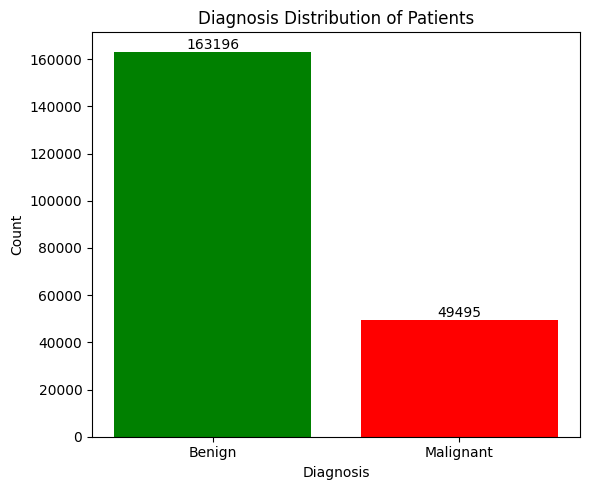

In [24]:
# Make barchart of diagnosis distribution
diagnosis_counts = df['Diagnosis'].value_counts()

diagnosis_color_map = {'Benign': 'green', 'Malignant': 'red'}
bar_colors = [diagnosis_color_map[diag] for diag in diagnosis_counts.index]

plt.figure(figsize=(6, 5))
bars = plt.bar(diagnosis_counts.index, diagnosis_counts.values, color=bar_colors)
plt.title('Diagnosis Distribution of Patients')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

# Add count labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

This bar chart illustrates the number of patients diagnosed with either benign or malignant thyroid conditions. A significant majority of the cases are benign 163,196, while 49,495 cases are malignant. This class imbalance is important to acknowledge when developing predictive models, as it can bias the model toward the majority class. Techniques such as oversampling the minority class or using balanced accuracy metrics may be necessary to ensure reliable performance across both diagnosis categories.

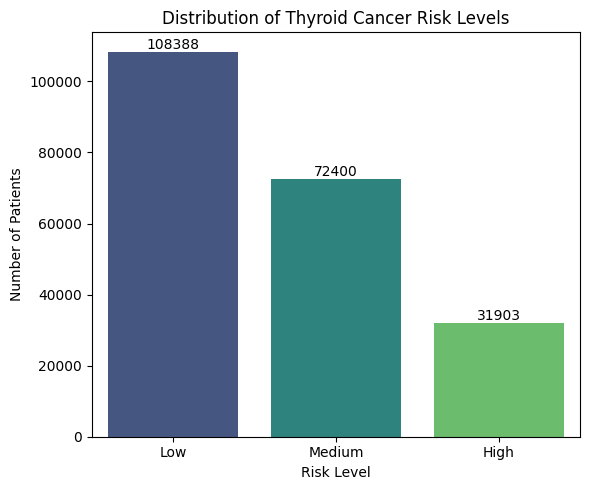

In [25]:
# Make barchart of thyroid cancer risk levels
risk_order = ['Low', 'Medium', 'High']

plt.figure(figsize=(6, 5))
ax = sns.countplot(
    data=df,
    x='Thyroid_Cancer_Risk',
    hue='Thyroid_Cancer_Risk',
    order=risk_order,
    palette='viridis',
    legend=False
)

# Add count labels on top
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

plt.title('Distribution of Thyroid Cancer Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

This bar chart shows the distribution of patients across three thyroid cancer risk categories: low, medium, and high. We can see that low risk patients form a substantial portion of the dataset, accounting for over half of all cases. This means that we have a class imbalance in this feature, which may need to be accounted for with class weights or oversampling.

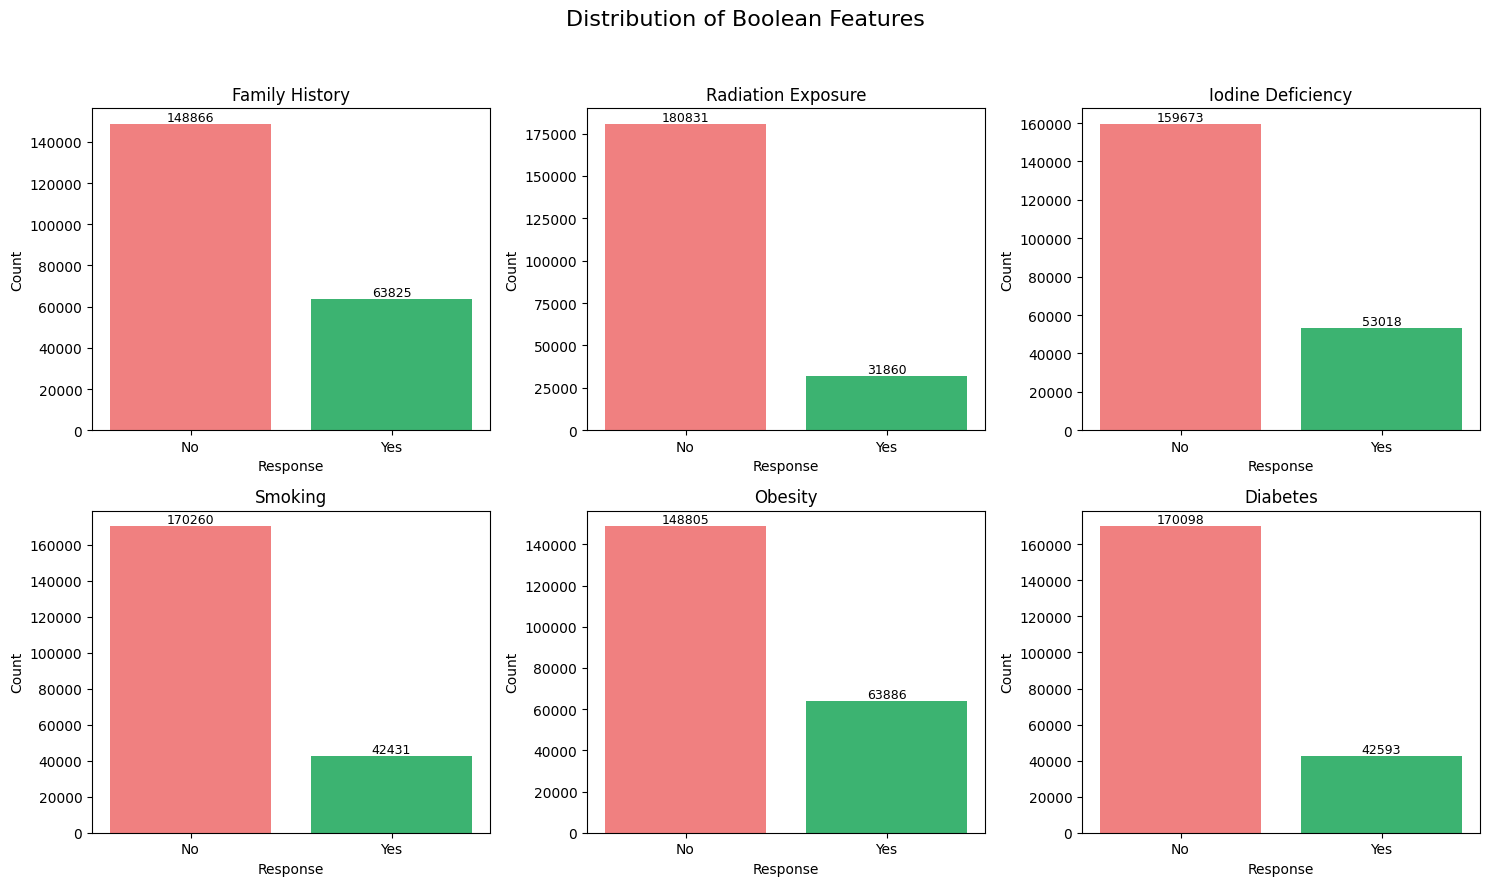

In [26]:
# Make a combined barchart for all boolean columns
boolean_cols = [
    'Family_History',
    'Radiation_Exposure',
    'Iodine_Deficiency',
    'Smoking',
    'Obesity',
    'Diabetes'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(boolean_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=['lightcoral', 'mediumseagreen'])
    axes[i].set_title(col.replace('_', ' '))
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('Response')

    # Add count labels
    for j, value in enumerate(counts.values):
        axes[i].text(j, value + 0.1, str(value), ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribution of Boolean Features', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

This collection of bar charts displays the distribution of binary (yes/no) responses for several important risk factors related to thyroid cancer, including:

Family History

Radiation Exposure

Iodine Deficiency

Smoking

Obesity

Diabetes

Across all features, the “No” responses dominate, indicating fewer patients reported having these risk factors. While these variables are less common, they may still have strong predictive power or clinical significance. Understanding their distribution is crucial when evaluating the influence of lifestyle and environmental factors on thyroid cancer risk. The imbalance also highlights the need for careful handling during model training to avoid underestimating the impact of less frequently occurring, but potentially high-risk, attributes.

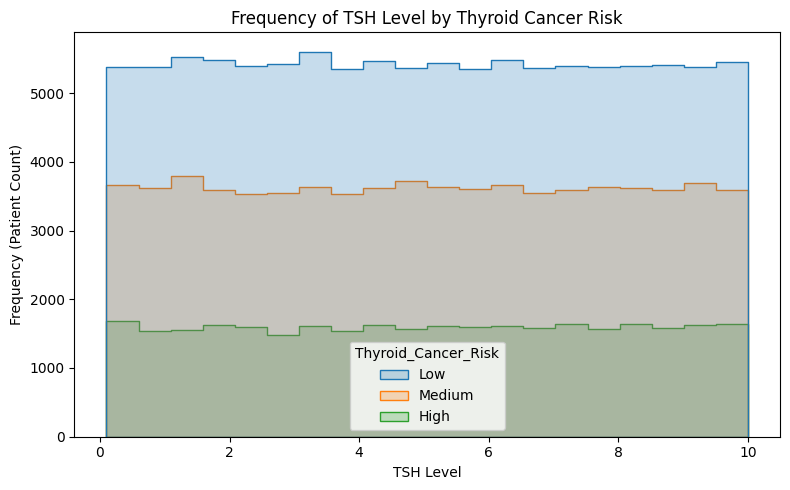

In [46]:
# Histogram: TSH Level (frequency)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='TSH_Level', hue='Thyroid_Cancer_Risk',
             bins=20, element='step', stat='count', common_norm=False)
plt.title('Frequency of TSH Level by Thyroid Cancer Risk')
plt.xlabel('TSH Level')
plt.ylabel('Frequency (Patient Count)')
plt.tight_layout()
plt.show()

This graph illustrates how TSH (Thyroid Stimulating Hormone) levels are distributed among patients with varying cancer risks. For instance, if High risk patients cluster around higher TSH values, this suggests that elevated TSH may be a potential marker for thyroid cancer. Conversely, a wide spread across all risk groups may indicate that TSH alone is not a strong predictor.

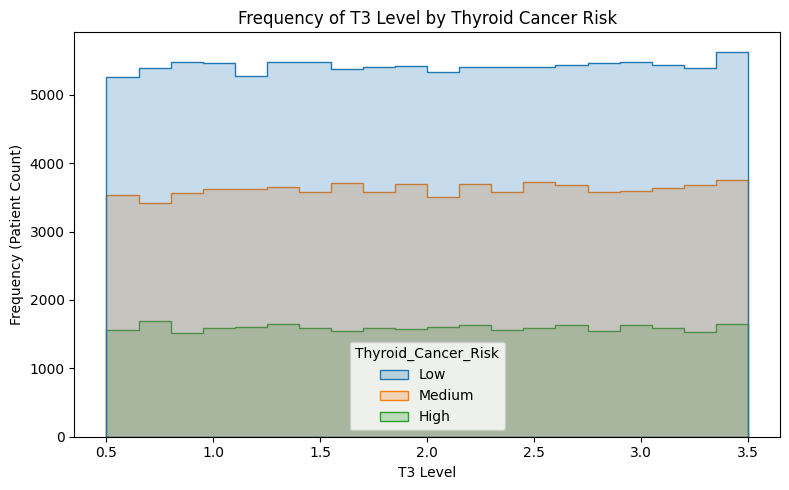

In [44]:
# Histogram: T3 Level (frequency)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='T3_Level', hue='Thyroid_Cancer_Risk',
             bins=20, element='step', stat='count', common_norm=False)
plt.title('Frequency of T3 Level by Thyroid Cancer Risk')
plt.xlabel('T3 Level')
plt.ylabel('Frequency (Patient Count)')
plt.tight_layout()
plt.show()

This plot shows the frequency of T3 hormone levels across risk categories. T3 is another critical thyroid hormone, and its imbalance can be associated with thyroid dysfunction. Noticing a higher frequency of High risk patients in the lower T3 range could suggest that T3 suppression is linked to malignancy.

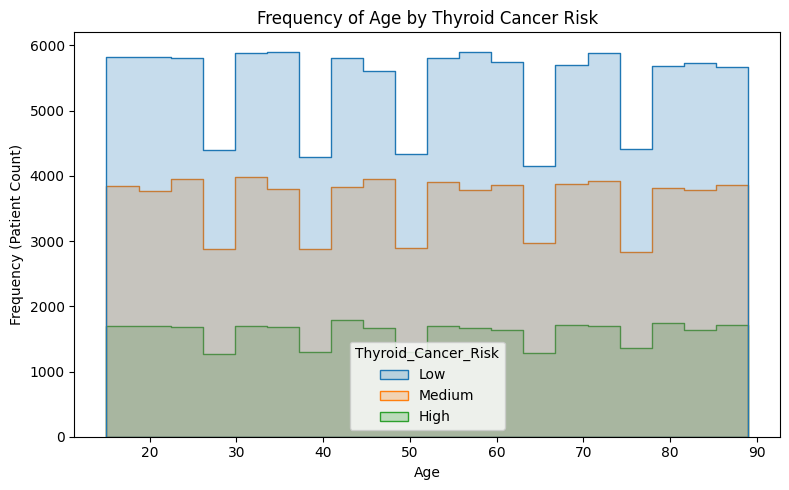

In [45]:
# Histogram: Age (frequency)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Thyroid_Cancer_Risk',
             bins=20, element='step', stat='count', common_norm=False)
plt.title('Frequency of Age by Thyroid Cancer Risk')
plt.xlabel('Age')
plt.ylabel('Frequency (Patient Count)')
plt.tight_layout()
plt.show()

The age distribution plot helps determine whether certain age groups are more frequently represented in higher risk categories. If older age bins (e.g., 60+) have a noticeably higher count of Medium or High risk patients, this supports the idea that age is a contributing risk factor in thyroid cancer diagnosis.

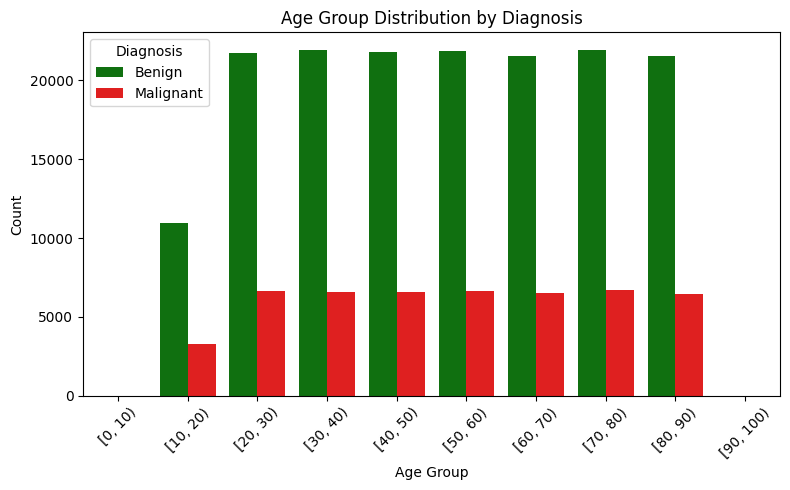

In [28]:
# Make barchart of age group distribution (in decades) with diagnosis
plt.figure(figsize=(8, 5))
sns.countplot(
    x=pd.cut(df['Age'], bins=range(0, 101, 10), right=False),
    hue=df['Diagnosis'],
    palette={'Benign': 'green', 'Malignant': 'red'}
)
plt.title('Age Group Distribution by Diagnosis')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This bar chart shows the distribution of benign and malignant thyroid diagnoses across different age groups. Each group displays a consistent pattern where benign cases significantly outnumber malignant ones. Interestingly, the number of malignant diagnoses appears relatively stable from ages 20 to 90, suggesting a persistent risk across adulthood. The even distribution of benign cases highlights that thyroid issues are prevalent across all age groups. This age-based breakdown helps identify whether certain age brackets may warrant closer screening or targeted preventative measures in future healthcare strategies.



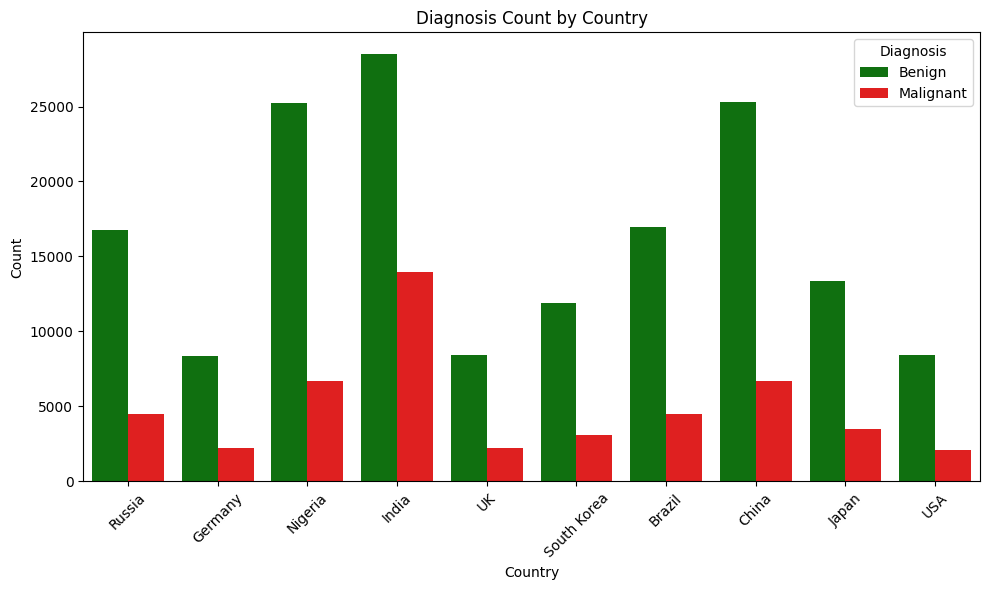

In [29]:
# Make barchart of diagnosis count by country
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='Country',
    hue='Diagnosis',
    palette={'Benign': 'green', 'Malignant': 'red'}
)

plt.title('Diagnosis Count by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

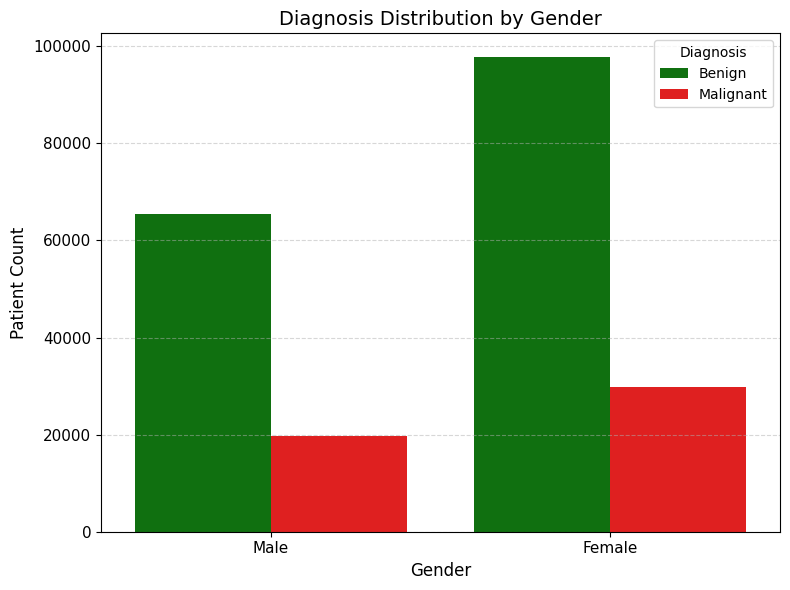

In [30]:
# Color palette: green for Benign, red for Malignant
custom_palette = {'Benign': 'green', 'Malignant': 'red'}

#Countplot: Diagnosis counts by Gender ---
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Gender', hue='Diagnosis', palette=custom_palette)
plt.title('Diagnosis Distribution by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)
plt.legend(title='Diagnosis', loc='upper right')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Diagnosis Distribution by Gender (Count Plot):
This bar chart displays the total number of patients diagnosed with benign or malignant thyroid conditions, grouped by gender. The use of green for benign and red for malignant provides an intuitive visual cue to distinguish between non-cancerous and cancerous outcomes.

- In the dataset shown, female patients make up a larger portion of the population and also account for a higher number of both benign and malignant cases compared to males.

- This graph is helpful for identifying overall volume differences between genders, which could be influenced by sampling, real-world incidence rates, or diagnostic behaviors.


## Provide measure of centraility and distribution with visuals

Statistics for Age:
  Count: 212691
  Mean: 51.918496786417855
  Std Dev: 21.632814529080814
  Min: 15
  25th Percentile: 33.0

Statistics for TSH_Level:
  Count: 212691
  Mean: 5.045102002435458
  Std Dev: 2.860264068976058
  Min: 0.1
  25th Percentile: 2.57

Statistics for T3_Level:
  Count: 212691
  Mean: 2.0017266362939665
  Std Dev: 0.8662480194769446
  Min: 0.5
  25th Percentile: 1.25

Statistics for T4_Level:
  Count: 212691
  Mean: 8.246203976660977
  Std Dev: 2.164188476007154
  Min: 4.5
  25th Percentile: 6.37

Statistics for Nodule_Size:
  Count: 212691
  Mean: 2.503403246963906
  Std Dev: 1.4446307307258648
  Min: 0.0
  25th Percentile: 1.25


TSH_Level - mu = 1.65, sigma = 0.59


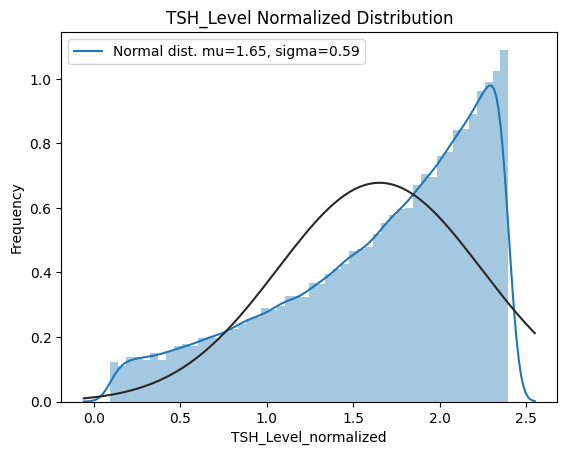


Nodule_Size - mu = 1.15, sigma = 0.48


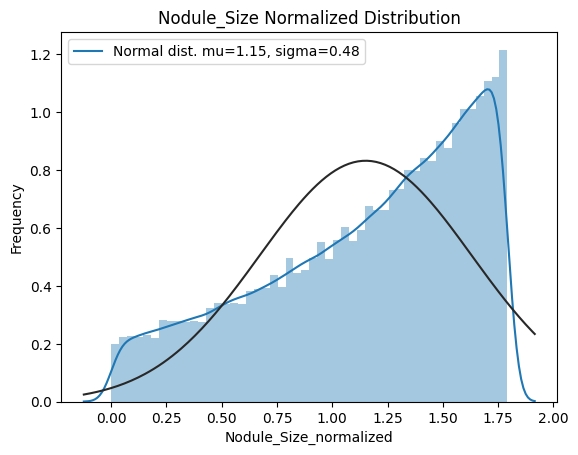


Skewness of original continuous features:
Age: 0.0
TSH_Level: 0.0
T3_Level: 0.0
T4_Level: 0.0
Nodule_Size: 0.0

Skewness of normalized versions:
TSH_Level_normalized: -0.78
Nodule_Size_normalized: -0.62


In [31]:
numeric_cols = ['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size']

#Calculations
for col in numeric_cols:
    print(f"Statistics for {col}:")
    print(f"  Count: {df[col].count()}")
    print(f"  Mean: {df[col].mean()}")
    print(f"  Std Dev: {df[col].std()}")
    print(f"  Min: {df[col].min()}")
    print(f"  25th Percentile: {df[col].quantile(0.25)}") #35% of values are less than or equal to, lower end of distribution, detect outliers
    print()


for col1 in ['TSH_Level', 'Nodule_Size']:
    # Apply log1p transformation
    transformed_col1 = f"{col1}_normalized"
    df[transformed_col1] = np.log1p(df[col1])

    # Plot histogram and fitted normal curve
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        sns.distplot(df[transformed_col1], fit=norm)
    mu, sigma = norm.fit(df[transformed_col1])
    print(f"\n{col1} - mu = {mu:.2f}, sigma = {sigma:.2f}")


    plt.legend(["Normal dist. mu={:.2f}, sigma={:.2f}".format(mu, sigma)], loc='best')
    plt.ylabel("Frequency")
    plt.title(f"{col1} Normalized Distribution")
    plt.show()

# Check skewness of all continuous numeric columns
continuous_columns = ['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size']

def clean_skew(value):
    # If the absolute skew is smaller than 0.005 then treat it as exactly 0
    return 0.00 if abs(value) < 0.005 else round(value, 2)

print("\nSkewness of original continuous features:")
for col2 in continuous_columns:
    skew_val = df[col2].skew()
    print(f"{col2}: {clean_skew(skew_val)}")

print("\nSkewness of normalized versions:")
for col3 in ['TSH_Level_normalized', 'Nodule_Size_normalized']:
    skew_val = df[col3].skew()
    print(f"{col3}: {clean_skew(skew_val):.2f}")

- Age

  - We can see that the mean is 51.9 years old, and since our standard deviation is 21.6, this indicates that there is a wide range of patient ages.

- TSH_Level
  - We can see that our mean is 5.05, with a standard deviation of 2.86. Since our 25th percentile is 2.57, we can see that our distribution is right-skewed.

- T3_Level and T4_Level
  - We can see that our mean for T3 is 2.0 and for T4 is 8.25. The standard deviation for T3 is 0.87, and for T4 it is 2.16. These distributions are relatively symmetric (based on the mean and percentiles).

- Nodule Size
  - We can see that our mean is 2.50, while our standard deviation is 1.44. Since the 25th percentile is at 1.25, this menas that we have a right-skewed distribution.


We can see that after log normalization, TSH_Level and Nodule_Size approximate a normal distribution. The histograms for these columns confirm a sharp positive skew in the original data, which is corrected to. a mild negative skew in the log-transformed version.


Peak score for TSH_Level: 1.80
The data is flatter and has fewer extreme values than normal.


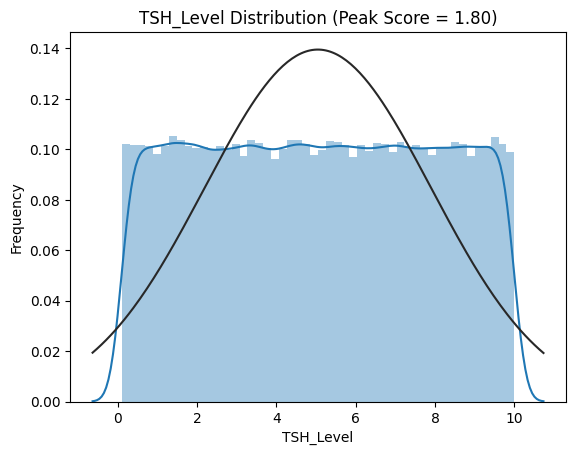


Peak score for Nodule_Size: 1.80
The data is flatter and has fewer extreme values than normal.


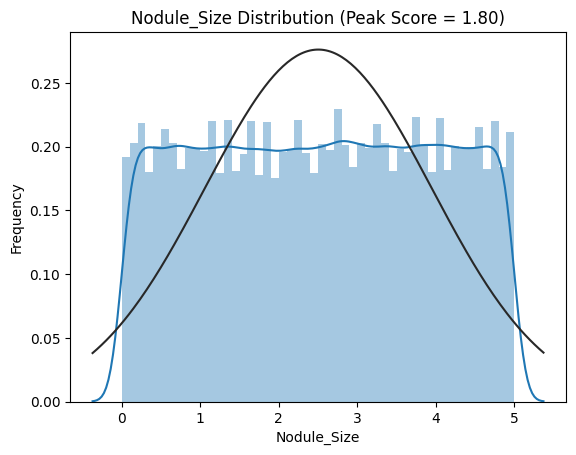

In [32]:
def peak_find(column):
#checks how sharp the peak is and whether there are many extreme values, outliers.

    values = column.dropna()  # Remove missing values
    n = len(values)
    mean = values.mean()
    std = values.std()

    if std == 0:
        print(f"\n{column.name}: All values are the same, no variation.")
        return

    # Manual "peak score" calculation (similar to kurtosis)
    fourth_moment = (((values - mean) / std) ** 4).sum() / n
    peak_score = fourth_moment

    print(f"\nPeak score for {column.name}: {fourth_moment:.2f}")

    if fourth_moment > 3:
        print("The data has a sharp peak and more extreme values than normal.")
    elif fourth_moment < 3:
        print("The data is flatter and has fewer extreme values than normal.")
    else:
        print("The data is shaped like a normal curve.")

    #Plot the distribution with normal curve
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        sns.distplot(values, fit=norm)

    plt.title(f"{column.name} Distribution (Peak Score = {peak_score:.2f})")
    plt.xlabel(column.name)
    plt.ylabel("Frequency")
    plt.show()

peak_find(df["TSH_Level"])
peak_find(df["Nodule_Size"])

We can see from that data and these graphs that both TSH_Level and Nodule_Size distributions are flatter and more uniform than a normal curve, with fewer extreme values and less central concentration. This suggests that the dataset is well-distributed across mid-range values.

This may lead to less distinction between classes based on these features alone.

## Diagnose for correlations between variables and determine independent and dependent variables

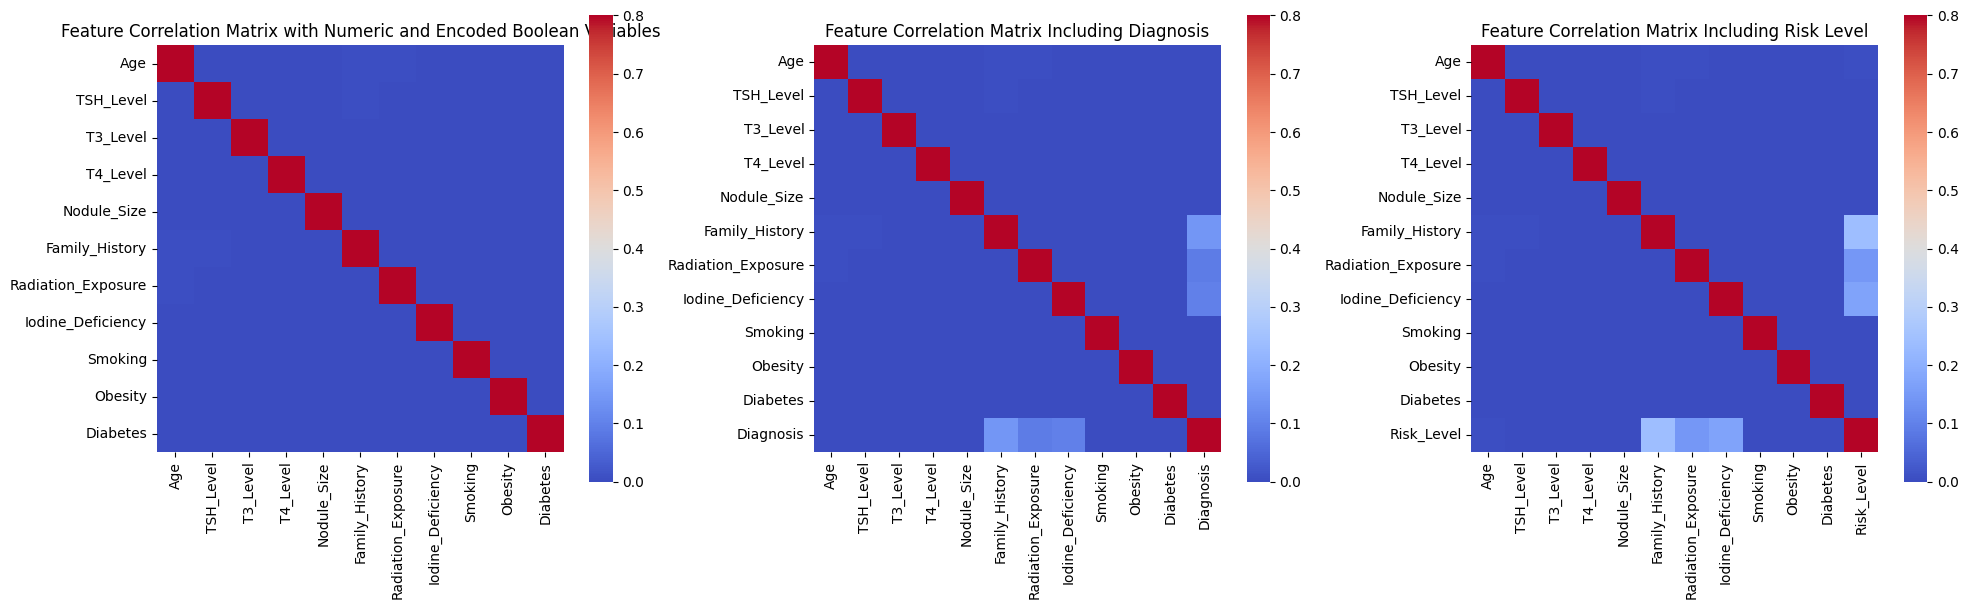

In [33]:
df_encoded = df.copy()

# Encode boolean-like string features to 0/1
bool_cols = ['Family_History', 'Radiation_Exposure', 'Iodine_Deficiency',
             'Smoking', 'Obesity', 'Diabetes']

for col in bool_cols:
    df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0}).astype(int)

# Map Diagnosis to binary if needed
if df_encoded['Diagnosis'].dtype == 'object':
    df_encoded['Diagnosis'] = df_encoded['Diagnosis'].map({'Benign': 0, 'Malignant': 1}).astype(int)

# Encode Risk Level as ordinal
if 'Thyroid_Cancer_Risk' in df_encoded.columns:
    risk_map = {'Low': 0, 'Medium': 1, 'High': 2}
    df_encoded['Risk_Level'] = df_encoded['Thyroid_Cancer_Risk'].map(risk_map).astype(int)
else:
    raise ValueError("Column 'Thyroid_Cancer_Risk' not found.")

# Feature subsets
features_base = ['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size'] + bool_cols
df_corr_base = df_encoded[features_base]
df_corr_diag = df_encoded[features_base + ['Diagnosis']]
df_corr_risk = df_encoded[features_base + ['Risk_Level']]

# Plot 3 side-by-side heatmaps
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(df_corr_base.corr(), ax=axes[0], cmap='coolwarm', vmin=0, vmax=0.8, square=True)
axes[0].set_title("Feature Correlation Matrix with Numeric and Encoded Boolean Variables")

sns.heatmap(df_corr_diag.corr(), ax=axes[1], cmap='coolwarm', vmin=0, vmax=0.8, square=True)
axes[1].set_title("Feature Correlation Matrix Including Diagnosis")

sns.heatmap(df_corr_risk.corr(), ax=axes[2], cmap='coolwarm', vmin=0, vmax=0.8, square=True)
axes[2].set_title("Feature Correlation Matrix Including Risk Level")

plt.tight_layout()
plt.show()

The left correlation matrix shows that there is little correlation between our boolean variables, which is ideal for most models.

The middle correlation matrix adds the target vraible, and it shows that most variables don't have any correlation, however Family_History, Radiation_Exposure, and Iodine_Deficiency did have some weak correlation.

The right correlation matrix adds the Risk_Level variable, and has similar results to the middle correlation matrix.

# Data Analytics <a class="anchor" id="data-analytics"></a>

In this section, we evaluate the performance of our model for predicting thyroid cancer outcomes. We use classification metrics such as accuracy, precision, recall, and F1-score, as outlined in our proposal. We also examine which clinical and demographic features most contribute to prediction outcomes using feature importance analysis.

### Identifying Independent and Dependent Variables

**Dependent Variable (Target):**   
- Diagnosis: binary classification (Benign(0), Malignant(1))

**Independent Variables (Features):**  
- *Demographic:* Age, Gender, Country_Brazil,	Country_China, Country_Germany	Country_India,	Country_Japan,	Country_Nigeria,	Country_Russia,	Country_South Korea,	Country_UK,	Country_USA,	Ethnicity_African,	Ethnicity_Asian,	Ethnicity_Caucasian,	Ethnicity_Hispanic,	Ethnicity_Middle Eastern
- *Behavioral:* Smoking, Obesity, Diabetes  
- *Environmental:* Radiation_Exposure, Iodine_Deficiency  
- *Genetic:* Family_History  
- *Engineered:* Size_Age_Interaction, TSH_T3_Ratio, Thyroid_Index
- *Clinical:* TSH_Level, T3_Level, T4_Level, Nodule_Size, Thyroid_Cancer_Risk(Which was calculated as low(0), medium(1), or high(2), based on previous diagnoses/treatment and is ordinally encoded)

These features are used by supervised learning models to identify patterns that predict a patient's thyroid cancer risk level or diagnosis outcome.

### Model Evaluation Summary

**Random Forest Classifier:**  
- Used as the primary algorithm due to its robustness and ability to handle nonlinear relationships
- Trained for binary diagnosis classification

**Evaluation Metrics:**   
- Precision: Proportion of positive predictions that are actually correct.  
- Recall (Sensitivity): Proportion of actual positives correctly identified.  
- F1-score: Harmonic mean of precision and recall, useful with class imbalance.
- We are no longer using accuracy as a metric because in the medical context, it could be dangerous: If 80% of our samples are benign and 20% are malignant, our model could get 80% accuracy just by predicting “benign” every time, while missing every malignant case.

**Cross-Validation Strategy:**  
- Stratified 5-fold cross-validation is used to ensure balanced representation of each class in both training and validation splits  
- This increases the generalizability and robustness of our performance estimates

**Feature Importance Analysis:**  
- Random Forest allows us to extract and rank features based on how much they contribute to the model’s predictive power  
- Top features are visualized and interpreted in the context of clinical significance


## Create Random Forest Model

Classification Report (5-Fold Cross-Validated Predictions):

              precision    recall  f1-score   support

      Benign       0.85      0.94      0.89    163196
   Malignant       0.70      0.44      0.54     49495

    accuracy                           0.83    212691
   macro avg       0.77      0.69      0.72    212691
weighted avg       0.81      0.83      0.81    212691



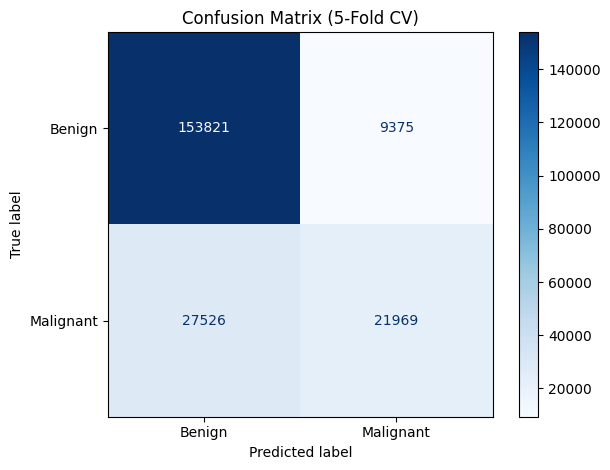

In [34]:
# Prepare input and target
X = encoded_df.drop(columns=['Diagnosis'])
y = encoded_df['Diagnosis']

# Initialize model
rf_diag = RandomForestClassifier(n_estimators=100, random_state=42)

# Stratified K-Fold and cross-validated predictions
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(rf_diag, X, y, cv=cv)

# Generate and print classification report
print("Classification Report (5-Fold Cross-Validated Predictions):\n")
print(classification_report(y, y_pred, target_names=['Benign', 'Malignant']))

# Confusion matrix visualization
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (5-Fold CV)")
plt.tight_layout()
plt.show()

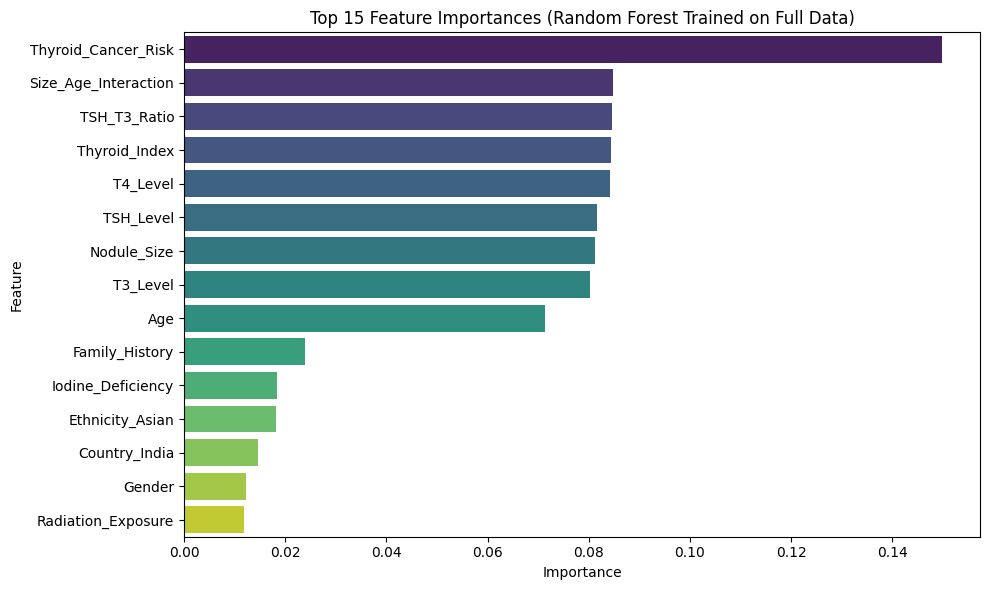

In [35]:
# We will now compute a bar chart of the most important features for this model
rf_diag_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_diag_final.fit(X, y)

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_diag_final.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importances.head(15),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title('Top 15 Feature Importances (Random Forest Trained on Full Data)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

We can see that the model is doing excellent for benign cases, however it is underperforming for malignant cases. This is due to the abundance of benign cases in the dataset compared to the malignant cases. We can also see that the numerical features of our dataset are the most important ones.

To improve performance, we'll try using SMOTE and add class_weight to the RandomForestClassifier

Classification Report (Manual 5-Fold with SMOTE in Training Only):

              precision    recall  f1-score   support

      Benign       0.85      0.90      0.88    163196
   Malignant       0.59      0.47      0.53     49495

    accuracy                           0.80    212691
   macro avg       0.72      0.69      0.70    212691
weighted avg       0.79      0.80      0.79    212691



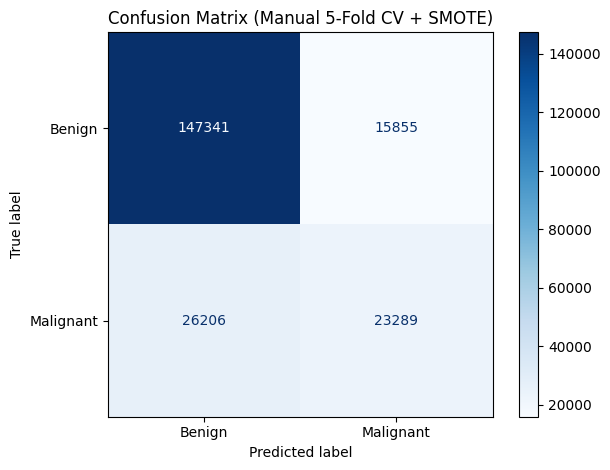

In [36]:
# Inputs
X = encoded_df.drop(columns=['Diagnosis'])
y = encoded_df['Diagnosis']

# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_true_all = []
y_pred_all = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Apply SMOTE to training fold only
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Train model
    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    model.fit(X_train_res, y_train_res)

    # Predict on test fold
    y_pred = model.predict(X_test)

    # Store results
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

# Final report
print("Classification Report (Manual 5-Fold with SMOTE in Training Only):\n")
print(classification_report(y_true_all, y_pred_all, target_names=['Benign', 'Malignant']))

cm = confusion_matrix(y_true_all, y_pred_all)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Manual 5-Fold CV + SMOTE)")
plt.tight_layout()
plt.show()

The SMOTE technique did not significantly improve the recall of malignant cases, therefore we will try a different model to see if we can improve that statistic.

## Create XGBoost Model

In [37]:
X = encoded_df.drop(columns=['Diagnosis'])
y_diag = encoded_df['Diagnosis'] # Binary target

# Split data for the binary diagnosis classification task
X_train_diag, X_test_diag, y_train_diag, y_test_diag = train_test_split(
    X, y_diag, stratify=y_diag, test_size=0.2, random_state=42)


xgb_diag = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_diag.fit(X_train_diag, y_train_diag)
y_pred_xgb_diag = xgb_diag.predict(X_test_diag)

print("XGBoost Classification Report for Diagnosis (Benign vs Malignant):")
print(classification_report(y_test_diag, y_pred_xgb_diag))

XGBoost Classification Report for Diagnosis (Benign vs Malignant):
              precision    recall  f1-score   support

           0       0.85      0.94      0.89     32640
           1       0.71      0.45      0.55      9899

    accuracy                           0.83     42539
   macro avg       0.78      0.70      0.72     42539
weighted avg       0.82      0.83      0.81     42539



In [38]:
cv = StratifiedKFold(n_splits=5)
xgb_scores = cross_val_score(xgb_diag, X, y_diag, cv=cv, scoring='f1')

# Print scores for each fold
for i, score in enumerate(xgb_scores, 1):
    print(f"Fold {i} F1 Score: {score:.4f}")

# Print average score
print(f"Mean Stratified 5-Fold F1 Score for XGBoost (Diagnosis): {xgb_scores.mean():.4f}")


Fold 1 F1 Score: 0.5393
Fold 2 F1 Score: 0.5454
Fold 3 F1 Score: 0.5409
Fold 4 F1 Score: 0.5481
Fold 5 F1 Score: 0.5435
Mean Stratified 5-Fold F1 Score for XGBoost (Diagnosis): 0.5435


These results from XGBoost are very similar to those found with RandomForestClassifier. This model has 0.4 improvement on benign recall, with a 0.2 decrease in malignant recall. These results still aren't ideal for predicting malignant cases, so we'll try using a few more different models.

## Test Various Models

In [40]:
# Features and target
X = encoded_df.drop(columns=['Diagnosis'])
y = encoded_df['Diagnosis']

# Scale numeric features (optional for tree-based models, important for others)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluation helper
def evaluate_model(model, model_name):
    print(f"\nEvaluating {model_name}")
    y_pred = cross_val_predict(model, X_scaled, y, cv=cv, n_jobs=-1)
    print(classification_report(y, y_pred, target_names=["Benign", "Malignant"]))
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"])
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()


Evaluating Logistic Regression
              precision    recall  f1-score   support

      Benign       0.85      0.69      0.76    163196
   Malignant       0.37      0.60      0.46     49495

    accuracy                           0.67    212691
   macro avg       0.61      0.65      0.61    212691
weighted avg       0.74      0.67      0.69    212691



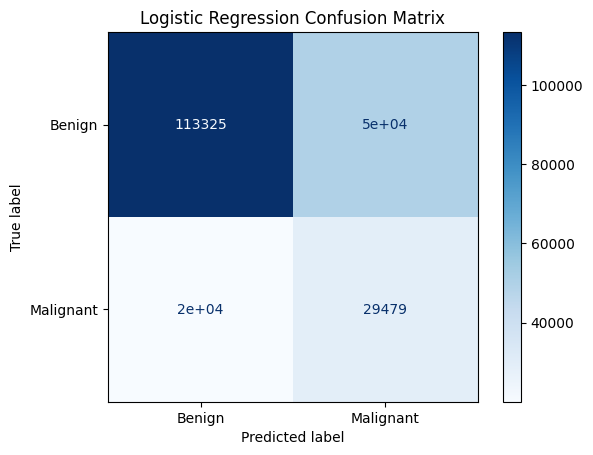

In [41]:
# Try a Logistic Regression Model
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
evaluate_model(logreg, "Logistic Regression")


Evaluating K-Nearest Neighbors
              precision    recall  f1-score   support

      Benign       0.83      0.93      0.88    163196
   Malignant       0.62      0.39      0.48     49495

    accuracy                           0.80    212691
   macro avg       0.73      0.66      0.68    212691
weighted avg       0.78      0.80      0.78    212691



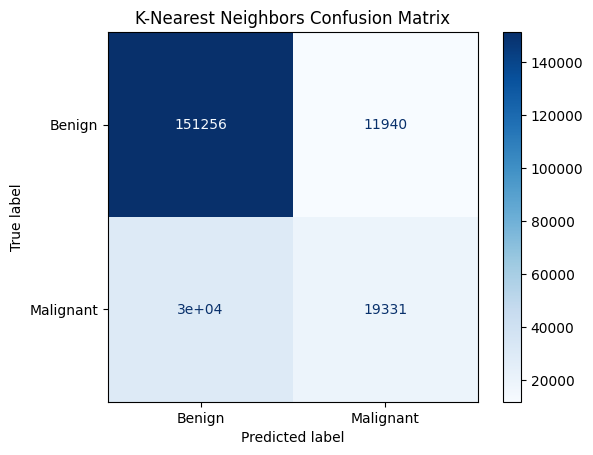

In [42]:
# Try K-Nearest-Neighbors Classifier Model
knn = KNeighborsClassifier(n_neighbors=5)
evaluate_model(knn, "K-Nearest Neighbors")


Evaluating Gradient Boosting
              precision    recall  f1-score   support

      Benign       0.85      0.94      0.89    163196
   Malignant       0.70      0.45      0.55     49495

    accuracy                           0.83    212691
   macro avg       0.77      0.70      0.72    212691
weighted avg       0.81      0.83      0.81    212691



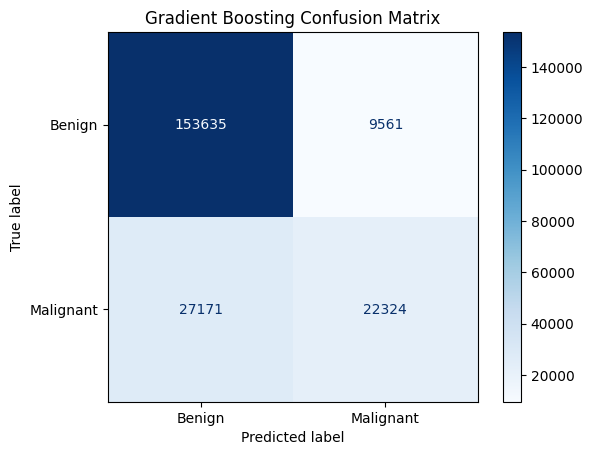

In [ ]:
# Try a Gradient Boosting Classifier Model
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
evaluate_model(gbc, "Gradient Boosting")


Evaluating AdaBoost
              precision    recall  f1-score   support

      Benign       0.85      0.94      0.89    163196
   Malignant       0.70      0.45      0.55     49495

    accuracy                           0.83    212691
   macro avg       0.78      0.70      0.72    212691
weighted avg       0.81      0.83      0.81    212691



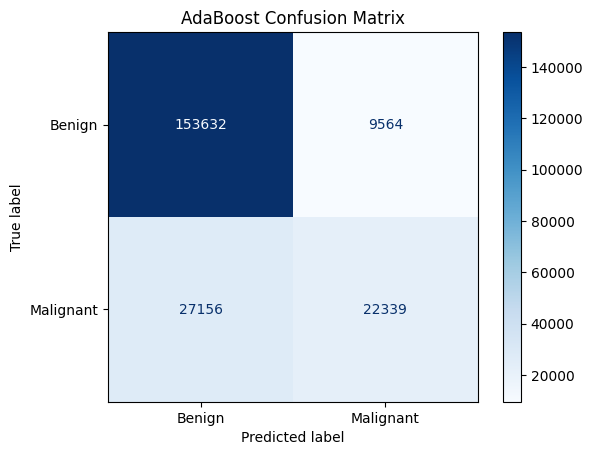

In [ ]:
# Try an Ada Boost Classiifer Model
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
evaluate_model(ada, "AdaBoost")


Evaluating Extra Trees Classifier
              precision    recall  f1-score   support

      Benign       0.84      0.94      0.89    163196
   Malignant       0.70      0.43      0.53     49495

    accuracy                           0.82    212691
   macro avg       0.77      0.68      0.71    212691
weighted avg       0.81      0.82      0.81    212691



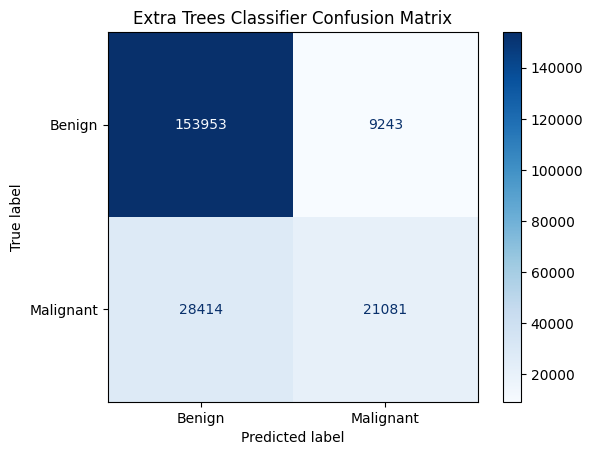

In [43]:
# Try an Extra Trees Classifier Model
etc = ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42)
evaluate_model(etc, "Extra Trees Classifier")


Evaluating Neural Network (MLP)
              precision    recall  f1-score   support

      Benign       0.85      0.94      0.89    163196
   Malignant       0.70      0.44      0.54     49495

    accuracy                           0.83    212691
   macro avg       0.77      0.69      0.72    212691
weighted avg       0.81      0.83      0.81    212691



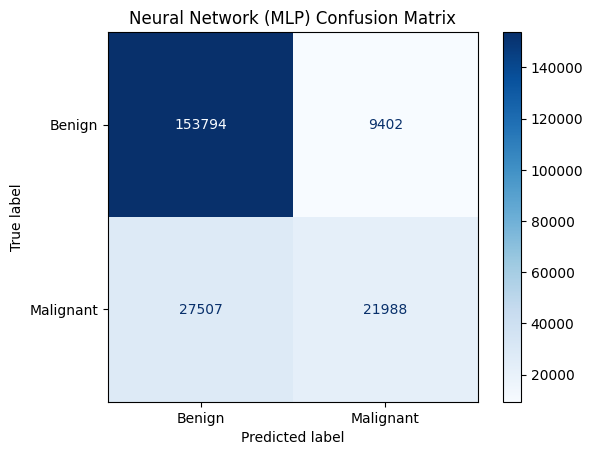

In [ ]:
# Try an MLP Classifier Model
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
evaluate_model(mlp, "Neural Network (MLP)")

## Compare Performance of Models

<Figure size 1200x600 with 0 Axes>

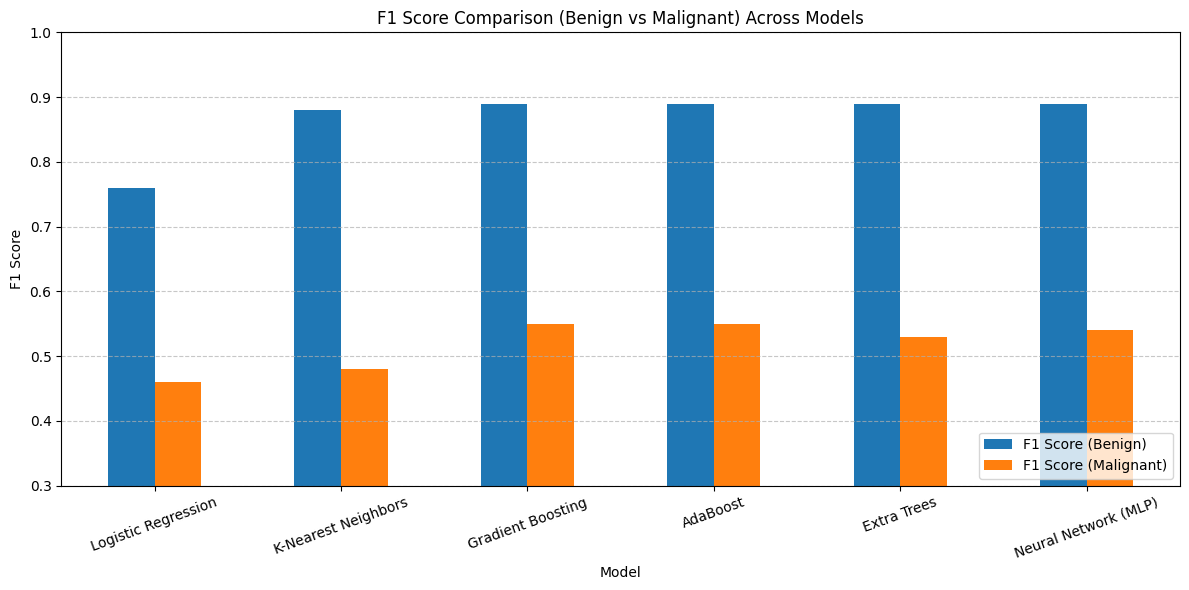

In [ ]:
# F1 score data for each model (based on your confusion matrices and reports)
model_comparison_data = {
    "Model": [
        "Logistic Regression", "K-Nearest Neighbors", "Gradient Boosting",
        "AdaBoost", "Extra Trees", "Neural Network (MLP)"
    ],
    "F1 Score (Benign)": [0.76, 0.88, 0.89, 0.89, 0.89, 0.89],
    "F1 Score (Malignant)": [0.46, 0.48, 0.55, 0.55, 0.53, 0.54]
}

# Create a DataFrame
f1_comparison_df = pd.DataFrame(model_comparison_data)

# Plotting
plt.figure(figsize=(12, 6))
f1_comparison_df.set_index("Model")[["F1 Score (Benign)", "F1 Score (Malignant)"]].plot(kind="bar", figsize=(12,6))
plt.title("F1 Score Comparison (Benign vs Malignant) Across Models")
plt.ylabel("F1 Score")
plt.ylim(0.3, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Conclusion
We can see that from all of our models generated, we can predict benign cases very well, having recall scores range from ~0.75 to ~0.89. Logistric Regression was significantly worse for benign f1-score than all of the other models that we used.

The best model we found was Gradient Boosting, which was able to had an f1-score for malignant cases of 0.55. This model can be confidently used to rule out cancer in many cases (when keeping other statistics in mind), however there is a clinical risk of missing malignant diagnoses which may lead to unnecessary treatments being given to patients that do not require them.

The stark difference between benign and malignant f1-scores reflects the class imbalance in the dataset. Models like these tend to be biased towards the majority class (benign), and rebalancing techniques like SMOTE were unable to improve the f1-score of malignant predictions without significantly affecting the f1-score of benign predictions.